Implementing Linear Regression from Scratch

f(x) = wx + b

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Generating the Data

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 3 * X + 7 + np.random.randn(100, 1) * 0.5

In [4]:
print(X[:5], y[:5])

[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]] [[ 9.29076425]
 [12.55478216]
 [11.43784404]
 [ 9.59816645]
 [ 7.8262759 ]]


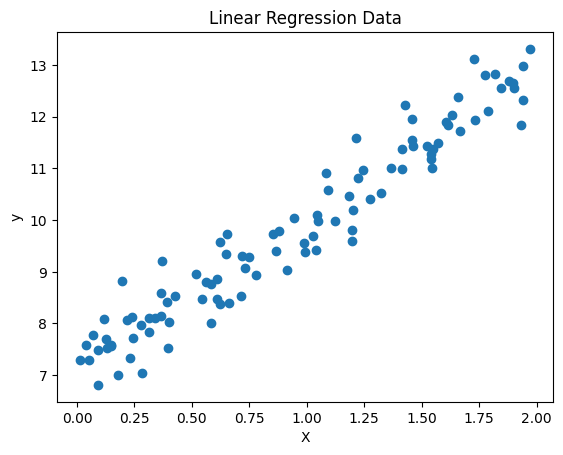

In [5]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Data")
plt.show()

Train Test Split

In [6]:
def train_test_split_numpy(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    # 1. Shuffle indices
    indices = np.random.permutation(len(X))
    
    # 2. Define split boundary
    test_samples = int(len(X) * test_size)
    train_indices = indices[test_samples:]
    test_indices = indices[:test_samples]
    
    # 3. Slice the data
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [7]:
X_train, X_test, y_train, y_test = train_test_split_numpy(X, y, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (80, 1) (80, 1)
Test shapes: (20, 1) (20, 1)


The X Function

In [12]:
def f(X, w, b):
    return X * w + b

Mean Squared Cost Function

In [10]:
m = len(y)

In [11]:
def compute_cost(X, y, w, b):
    predictions = X * w + b
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [9]:
cost = compute_cost(X_train, y_train, w=0, b=0)
print("Initial cost:", cost)

Initial cost: 49.41624033651409


Implementing the Gradient Descent

In [19]:
w = 0.0
b = 0.0
alpha = 0.01
num_iterations = 10000

In [20]:
def derivative(X, y, w, b):
    m = len(y)
    dw = (1 / m) * np.sum((f(X, w, b) - y) * X)
    db = (1 / m) * np.sum(f(X, w, b) - y)
    return dw, db

In [21]:
def fit(X, y, w, b, alpha, num_iterations):
    for i in range(num_iterations):
        dw, db = derivative(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            print(f"Iteration {i}: Cost {cost:.4f}, w {w:.4f}, b {b:.4f}")
    return w, b

In [22]:
w, b = fit(X_train, y_train, w, b, alpha, num_iterations)
print(f"Trained parameters: w {w:.4f}, b {b:.4f}")

Iteration 0: Cost 37.9597, w 0.1015, b 0.0979
Iteration 100: Cost 1.2056, w 4.1521, b 4.3923
Iteration 200: Cost 0.4757, w 4.4175, b 5.2082
Iteration 300: Cost 0.3589, w 4.2434, b 5.5438
Iteration 400: Cost 0.2815, w 4.0455, b 5.7834
Iteration 500: Cost 0.2260, w 3.8716, b 5.9808
Iteration 600: Cost 0.1862, w 3.7233, b 6.1474
Iteration 700: Cost 0.1576, w 3.5976, b 6.2884
Iteration 800: Cost 0.1371, w 3.4911, b 6.4080
Iteration 900: Cost 0.1223, w 3.4008, b 6.5092
Iteration 1000: Cost 0.1117, w 3.3243, b 6.5950
Iteration 1100: Cost 0.1041, w 3.2595, b 6.6677
Iteration 1200: Cost 0.0987, w 3.2046, b 6.7294
Iteration 1300: Cost 0.0947, w 3.1581, b 6.7816
Iteration 1400: Cost 0.0919, w 3.1186, b 6.8258
Iteration 1500: Cost 0.0899, w 3.0852, b 6.8633
Iteration 1600: Cost 0.0885, w 3.0569, b 6.8951
Iteration 1700: Cost 0.0874, w 3.0329, b 6.9220
Iteration 1800: Cost 0.0867, w 3.0126, b 6.9448
Iteration 1900: Cost 0.0861, w 2.9953, b 6.9641
Iteration 2000: Cost 0.0858, w 2.9807, b 6.9805
Ite

In [24]:
def predict(X, w = w, b = b):
    return f(X, w, b)

In [27]:
def plot_regression_line(X, y, w = w, b = b):
    plt.scatter(X, y, color="blue", label="Actual Data")

    y_pred = predict(X)

    # 3. Plot the line
    plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")

    plt.xlabel("Feature (X)")
    plt.ylabel("Target (y)")
    plt.title("Linear Regression Fit")
    plt.legend()
    plt.show()

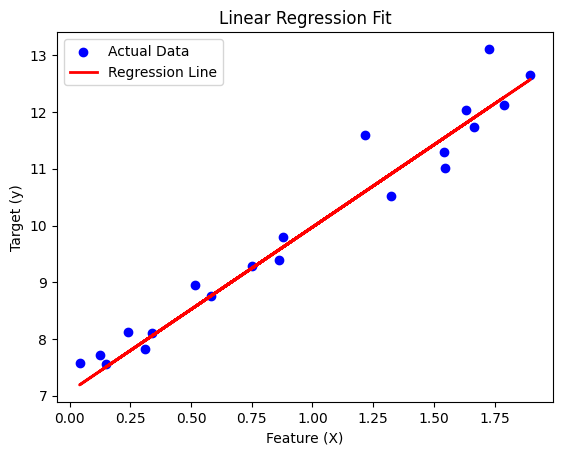

In [28]:
plot_regression_line(X_test, y_test)

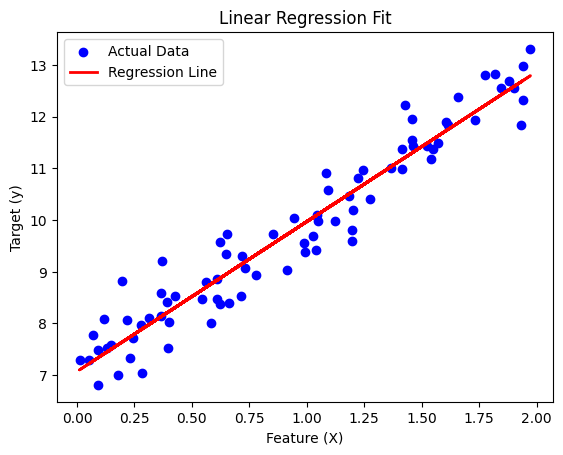

In [29]:
plot_regression_line(X_train, y_train)